# T3 — Paso 4: Estabilidad e interpretación

**Grupo 01** — Aplicaciones de IA en Estructuras, UPC

El principio de **Estabilidad** del marco PCS exige que las conclusiones se mantengan ante
perturbaciones razonables. En el paso 3 se obtuvieron tres conclusiones con **una sola**
partición de los datos. Aquí se ponen a prueba:

1. **Perturbación de los datos:** se repite toda la comparación con 10 particiones distintas
   entrenamiento/prueba (otros sismos de prueba cada vez).
2. **Perturbación de las decisiones de criterio:** se repite con los escenarios alternativos
   del notebook 02 (otro rango de magnitud y distancia, Rjb en lugar de Rrup, solo Vs30 de
   clase 0).
3. **Interpretación con SHAP:** se verifica qué variables usa el modelo y si su efecto tiene
   sentido físico, y si esa explicación se mantiene entre particiones.

Los hiperparámetros se mantienen fijos (los del paso 2) en todas las repeticiones.

In [1]:
import sys
sys.path.append("..")

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from src import config
from src.datos import cargar_flatfile, limpiar, aplicar_decisiones, particion_por_sismo
from src.ajuste import modelos_ajustados
from src.evaluacion import evaluar, verificar_monotonia

sns.set_theme(style="whitegrid")

COLORES = {
    "Línea base (GMPE)": "#7f7f7f",
    "Random Forest": "#2ca02c",
    "XGBoost": "#1f77b4",
    "XGBoost monótono": "#d62728",
    "Red neuronal": "#ff7f0e",
}

# Se carga el flatfile una sola vez; cada escenario parte de esta copia limpia
limpio = limpiar(cargar_flatfile())
print(f"Registros limpios: {len(limpio):,}")

Registros limpios: 21,293


In [2]:
def correr(df, semilla):
    """Partición con `semilla`, entrena los cinco modelos y devuelve métricas y física."""
    train, test = particion_por_sismo(df, semilla=semilla)
    tabla, entrenados = evaluar(modelos_ajustados(), train, test)
    for nombre, modelo in entrenados.items():
        v = verificar_monotonia(modelo)
        tabla.loc[nombre, "% violaciones"] = max(v.values())
    tabla["mejora vs base"] = tabla.loc["Línea base (GMPE)", "RMSE"] - tabla["RMSE"]
    return tabla.reset_index(), entrenados

## 1. Estabilidad ante la partición de los datos

Se repite la evaluación con 10 semillas. Cada semilla elige un conjunto distinto de sismos
de prueba (20 % de los 403). Tiempo estimado: algunos minutos.

In [3]:
final = aplicar_decisiones(limpio)
SEMILLAS = range(10)

filas = []
for s in SEMILLAS:
    tabla, _ = correr(final, s)
    tabla["semilla"] = s
    filas.append(tabla)
    print(f"Semilla {s}: listo")

particiones = pd.concat(filas, ignore_index=True)

Semilla 0: listo
Semilla 1: listo
Semilla 2: listo
Semilla 3: listo
Semilla 4: listo
Semilla 5: listo
Semilla 6: listo
Semilla 7: listo
Semilla 8: listo
Semilla 9: listo


In [4]:
resumen = particiones.groupby("modelo").agg(
    RMSE_medio=("RMSE", "mean"),
    RMSE_min=("RMSE", "min"),
    RMSE_max=("RMSE", "max"),
    mejora_media=("mejora vs base", "mean"),
    veces_que_mejora=("mejora vs base", lambda x: int((x > 0).sum())),
    violaciones_max=("% violaciones", "max"),
)
resumen["veces_que_mejora"] = resumen["veces_que_mejora"].astype(str) + f" de {len(SEMILLAS)}"
resumen.sort_values("RMSE_medio").round(3)

,RMSE_medio,RMSE_min,RMSE_max,mejora_media,veces_que_mejora,violaciones_max
modelo,,,,,,
XGBoost,0.814,0.750,0.915,0.141,10 de 10,19.896
Random Forest,0.820,0.735,0.909,0.135,10 de 10,21.979
Red neuronal,0.831,0.775,0.910,0.124,10 de 10,13.438
XGBoost monótono,0.833,0.777,0.898,0.122,10 de 10,0.000
Línea base (GMPE),0.955,0.845,1.053,0.000,0 de 10,0.000


In [5]:
ganador = particiones[particiones["modelo"] != "Línea base (GMPE)"].loc[
    lambda d: d.groupby("semilla")["RMSE"].idxmin()]
print("Modelo con menor RMSE en cada partición:")
print(ganador["modelo"].value_counts().to_string())

Modelo con menor RMSE en cada partición:
modelo
Random Forest       4
XGBoost             4
XGBoost monótono    1
Red neuronal        1


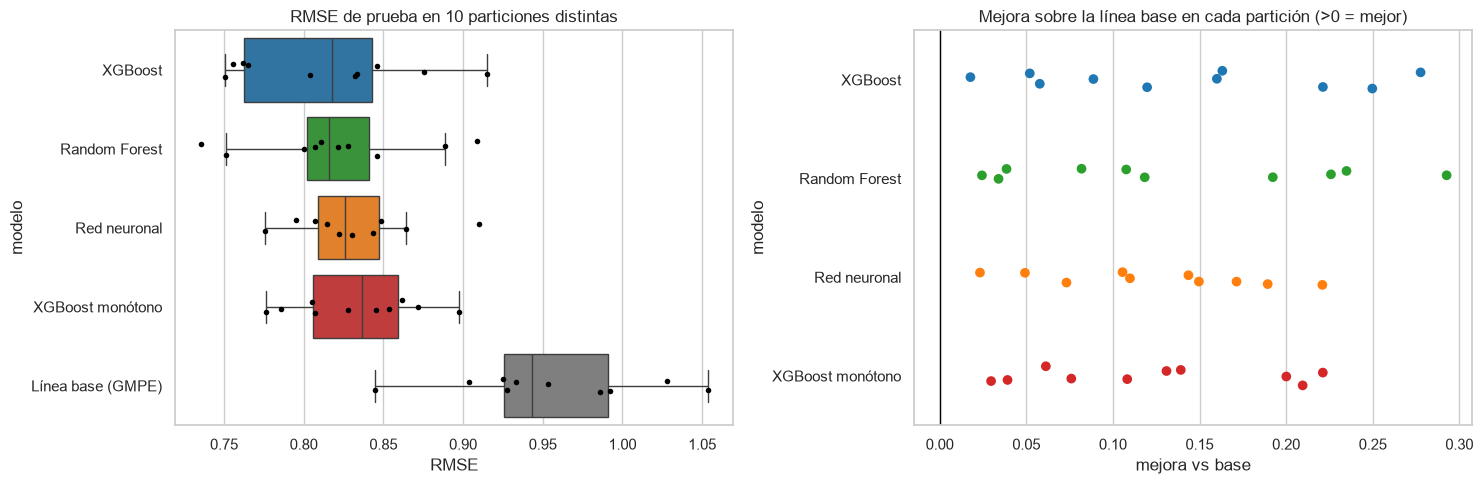

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

orden = particiones.groupby("modelo")["RMSE"].mean().sort_values().index
sns.boxplot(data=particiones, x="RMSE", y="modelo", order=orden,
            palette=COLORES, ax=axes[0], showfliers=False)
sns.stripplot(data=particiones, x="RMSE", y="modelo", order=orden,
              color="black", size=4, ax=axes[0])
axes[0].set_title("RMSE de prueba en 10 particiones distintas")

ml = particiones[particiones["modelo"] != "Línea base (GMPE)"]
orden_ml = [m for m in orden if m != "Línea base (GMPE)"]
sns.stripplot(data=ml, x="mejora vs base", y="modelo", order=orden_ml,
              palette=COLORES, size=7, ax=axes[1])
axes[1].axvline(0, color="black", lw=1)
axes[1].set_title("Mejora sobre la línea base en cada partición (>0 = mejor)")

plt.tight_layout()
plt.savefig("../results/estabilidad_particiones.png", dpi=150, bbox_inches="tight")
plt.show()

## 2. Estabilidad ante las decisiones de criterio

Mismo procedimiento, con la partición de referencia (semilla 42), cambiando una decisión
del T2 a la vez.

In [7]:
clase0 = limpio[limpio["vs30_clase"].astype(str) == "0"]

escenarios = {
    "Referencia (Mw≥4, Rrup≤200)": aplicar_decisiones(limpio),
    "Mw≥3, Rrup≤400": aplicar_decisiones(limpio, mw_min=3.0, r_max=400.0),
    "Mw≥4, Rrup≤300": aplicar_decisiones(limpio, r_max=300.0),
    "Distancia Rjb": aplicar_decisiones(limpio, distancia="Rjb"),
    "Solo Vs30 clase 0": aplicar_decisiones(clase0),
}

filas = []
for nombre, df in escenarios.items():
    tabla, _ = correr(df, config.SEED)
    tabla["escenario"] = nombre
    tabla["registros"] = len(df)
    filas.append(tabla)
    print(f"{nombre:30s} {len(df):6,} registros  listo")

criterio = pd.concat(filas, ignore_index=True)

Referencia (Mw≥4, Rrup≤200)    12,382 registros  listo
Mw≥3, Rrup≤400                 20,958 registros  listo
Mw≥4, Rrup≤300                 14,643 registros  listo
Distancia Rjb                  12,388 registros  listo
Solo Vs30 clase 0               4,442 registros  listo


In [8]:
rmse = criterio.pivot(index="escenario", columns="modelo", values="RMSE")
rmse = rmse.loc[list(escenarios)]
rmse["mejor modelo ML"] = rmse.drop(columns="Línea base (GMPE)").idxmin(axis=1)
rmse.round(3)

modelo,Línea base (GMPE),Random Forest,Red neuronal,XGBoost,XGBoost monótono,mejor modelo ML
escenario,,,,,,
"Referencia (Mw≥4, Rrup≤200)",0.865,0.821,0.813,0.813,0.818,Red neuronal
"Mw≥3, Rrup≤400",0.894,0.803,0.827,0.829,0.825,Random Forest
"Mw≥4, Rrup≤300",0.894,0.829,0.803,0.838,0.839,Red neuronal
Distancia Rjb,0.856,0.816,0.811,0.808,0.810,XGBoost
Solo Vs30 clase 0,0.855,0.740,0.772,0.748,0.742,Random Forest


In [9]:
viol = criterio.pivot(index="escenario", columns="modelo", values="% violaciones").loc[list(escenarios)]
print("% máximo de tramos que violan la monotonía física, por escenario:")
viol.round(1)

% máximo de tramos que violan la monotonía física, por escenario:


modelo,Línea base (GMPE),Random Forest,Red neuronal,XGBoost,XGBoost monótono
escenario,,,,,
"Referencia (Mw≥4, Rrup≤200)",0.0,15.4,12.4,16.2,0.0
"Mw≥3, Rrup≤400",0.0,14.7,0.5,0.0,0.0
"Mw≥4, Rrup≤300",0.0,16.2,13.2,19.1,0.0
Distancia Rjb,0.0,16.0,12.0,15.1,0.0
Solo Vs30 clase 0,0.0,20.2,0.6,6.2,0.0


## 3. Interpretación con SHAP

SHAP descompone cada predicción en la contribución de cada variable. Se aplica al modelo
que cumplió el criterio de éxito (**XGBoost monótono**) y, para comparar, al XGBoost sin
restricción.

Nota: la correlación entre magnitud y distancia en el dataset final es casi nula
(r ≈ 0.01, notebook 02), por lo que las contribuciones de SHAP de estas dos variables se
pueden interpretar por separado, una preocupación planteada en el T1.

In [10]:
train, test = particion_por_sismo(final, semilla=config.SEED)
_, entrenados = evaluar(modelos_ajustados(), train, test)

X_test = test[config.VARIABLES_ML]
nombres = ["Magnitud (Mw)", "ln Distancia", "ln Vs30", "Profundidad", "Mecanismo"]

valores_shap = {}
for nombre in ["XGBoost monótono", "XGBoost"]:
    arbol = entrenados[nombre].named_steps["modelo"]
    valores_shap[nombre] = shap.TreeExplainer(arbol)(X_test)
    valores_shap[nombre].feature_names = nombres

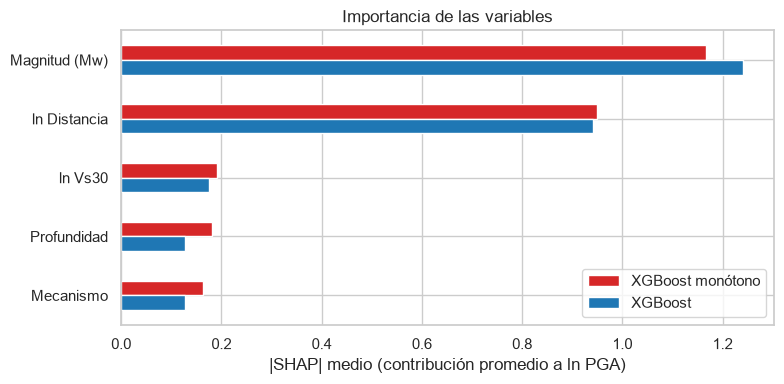

,XGBoost monótono,XGBoost
Magnitud (Mw),1.167,1.241
ln Distancia,0.949,0.942
ln Vs30,0.191,0.175
Profundidad,0.181,0.127
Mecanismo,0.163,0.128


In [11]:
importancia = pd.DataFrame({
    nombre: np.abs(v.values).mean(axis=0) for nombre, v in valores_shap.items()
}, index=nombres).sort_values("XGBoost monótono", ascending=False)

ax = importancia.plot.barh(figsize=(8, 4), color=[COLORES["XGBoost monótono"], COLORES["XGBoost"]])
ax.invert_yaxis()
ax.set_xlabel("|SHAP| medio (contribución promedio a ln PGA)")
ax.set_title("Importancia de las variables")
plt.tight_layout()
plt.savefig("../results/shap_importancia.png", dpi=150, bbox_inches="tight")
plt.show()
importancia.round(3)

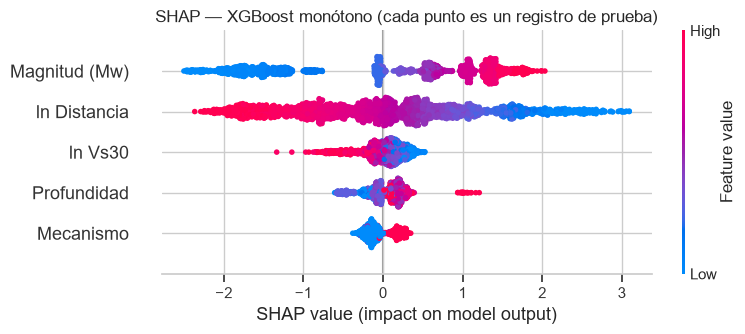

In [12]:
shap.plots.beeswarm(valores_shap["XGBoost monótono"], show=False)
plt.title("SHAP — XGBoost monótono (cada punto es un registro de prueba)")
plt.tight_layout()
plt.savefig("../results/shap_beeswarm.png", dpi=150, bbox_inches="tight")
plt.show()

### 3.1 Efecto de la distancia y la magnitud

Gráfico de dependencia: cómo cambia la contribución de cada variable a lo largo de su rango.
Para la distancia se espera una curva que **baja** de forma continua y que se **aplana a
corta distancia** (saturación). Para la magnitud, una curva que **sube**.

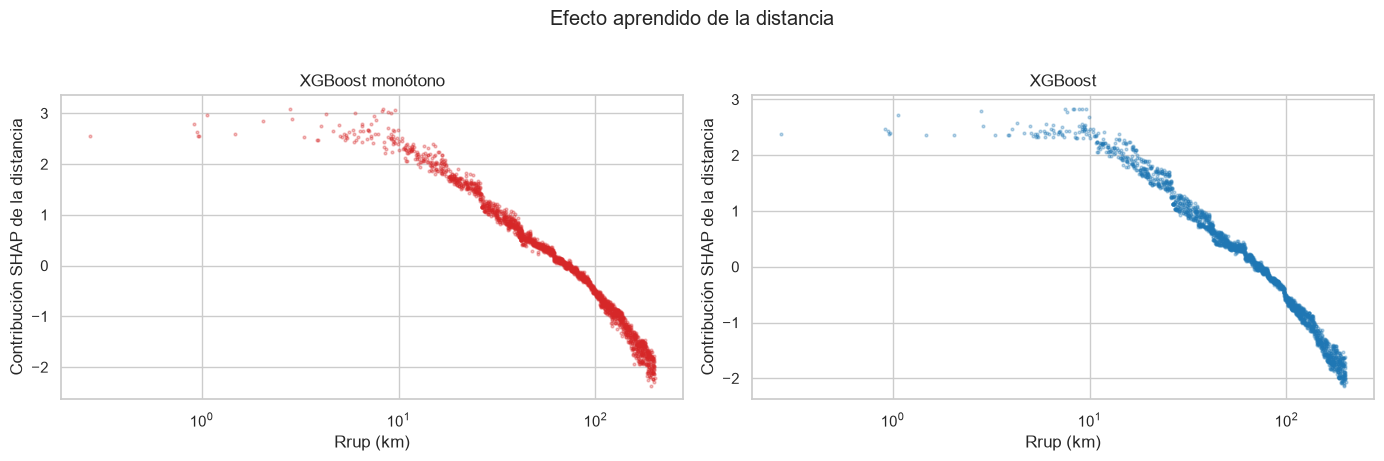

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), sharey=False)
for ax, nombre in zip(axes, ["XGBoost monótono", "XGBoost"]):
    v = valores_shap[nombre]
    R = np.sqrt(np.exp(X_test["lnR"]) ** 2 - config.H_SATURACION ** 2).clip(lower=0.1)
    ax.scatter(R, v[:, "ln Distancia"].values, s=4, alpha=0.3, color=COLORES[nombre])
    ax.set_xscale("log")
    ax.set_xlabel("Rrup (km)")
    ax.set_ylabel("Contribución SHAP de la distancia")
    ax.set_title(nombre)
plt.suptitle("Efecto aprendido de la distancia", y=1.02)
plt.tight_layout()
plt.savefig("../results/shap_distancia.png", dpi=150, bbox_inches="tight")
plt.show()

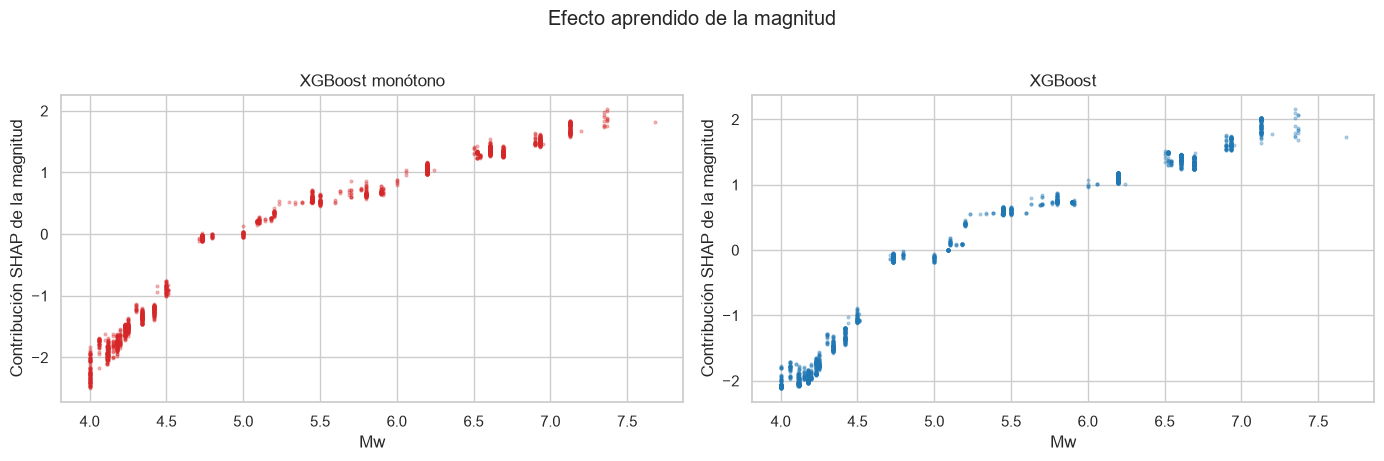

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
for ax, nombre in zip(axes, ["XGBoost monótono", "XGBoost"]):
    v = valores_shap[nombre]
    ax.scatter(X_test["Mw"], v[:, "Magnitud (Mw)"].values, s=4, alpha=0.3, color=COLORES[nombre])
    ax.set_xlabel("Mw")
    ax.set_ylabel("Contribución SHAP de la magnitud")
    ax.set_title(nombre)
plt.suptitle("Efecto aprendido de la magnitud", y=1.02)
plt.tight_layout()
plt.savefig("../results/shap_magnitud.png", dpi=150, bbox_inches="tight")
plt.show()

### 3.2 Estabilidad de la explicación

¿El orden de importancia de las variables se mantiene si cambian los sismos de
entrenamiento? Se recalcula SHAP del XGBoost monótono en las 10 particiones.

In [15]:
rankings = []
for s in SEMILLAS:
    tr, te = particion_por_sismo(final, semilla=s)
    modelo = modelos_ajustados()["XGBoost monótono"]
    modelo.fit(tr[config.VARIABLES_ML], tr[config.OBJETIVO])
    v = shap.TreeExplainer(modelo.named_steps["modelo"])(te[config.VARIABLES_ML])
    imp = pd.Series(np.abs(v.values).mean(axis=0), index=nombres)
    rankings.append(imp.rank(ascending=False).astype(int))

rankings = pd.DataFrame(rankings, index=[f"semilla {s}" for s in SEMILLAS])
print("Posición de cada variable en el ranking de importancia (1 = la más importante):")
rankings

Posición de cada variable en el ranking de importancia (1 = la más importante):


,Magnitud (Mw),ln Distancia,ln Vs30,Profundidad,Mecanismo
semilla 0,1,2,3,4,5
semilla 1,1,2,4,3,5
semilla 2,2,1,4,3,5
semilla 3,1,2,5,3,4
semilla 4,1,2,3,5,4
semilla 5,1,2,4,3,5
semilla 6,1,2,4,3,5
semilla 7,1,2,4,3,5
semilla 8,1,2,4,3,5
semilla 9,1,2,4,3,5


In [16]:
print("Frecuencia de cada posición por variable:")
rankings.apply(lambda col: col.value_counts()).fillna(0).astype(int).T

Frecuencia de cada posición por variable:


,1,2,3,4,5
Magnitud (Mw),9,1,0,0,0
ln Distancia,1,9,0,0,0
ln Vs30,0,0,2,7,1
Profundidad,0,0,8,1,1
Mecanismo,0,0,0,2,8


In [17]:
# Guardar resultados para el informe
particiones.round(4).to_csv(config.DIR_RESULTADOS / "estabilidad_particiones.csv", index=False, encoding="utf-8-sig")
criterio.round(4).to_csv(config.DIR_RESULTADOS / "estabilidad_escenarios.csv", index=False, encoding="utf-8-sig")
importancia.round(4).to_csv(config.DIR_RESULTADOS / "shap_importancia.csv", encoding="utf-8-sig")
print("Guardado en results/: estabilidad_particiones.csv, estabilidad_escenarios.csv, shap_importancia.csv")

Guardado en results/: estabilidad_particiones.csv, estabilidad_escenarios.csv, shap_importancia.csv


## 4. Lectura para el informe

1. **¿La mejora sobre la línea base se repite en todas las particiones?** Contar en
   cuántas de las 10 mejora cada modelo (sección 1). Esto complementa el bootstrap del paso 3.
2. **¿El ganador es siempre el mismo?** Si cambia entre particiones, las diferencias entre
   modelos de ML no son significativas; lo robusto es la diferencia frente a la línea base.
3. **¿El XGBoost monótono mantiene 0 % de violaciones en todos los escenarios?** Por
   construcción debería; los demás modelos probablemente no.
4. **¿Qué variables dominan y el efecto tiene sentido físico?** Magnitud y distancia
   deberían dominar, con los signos esperados; el Vs30 en tercer lugar.
5. **¿El orden de importancia es estable?** Ver la tabla de rankings de la sección 3.2.